In [1]:
# Import Required Libraries
import torch 
import torchvision
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch.utils.data as dataloader
import torch.nn as nn

In [2]:
# Transformation of PIL data into tensor format
transformation_operation = transforms.Compose([transforms.ToTensor()])

In [3]:
# Downloading Training and validation dataset from pytorch Image Library 

train_dataset = torchvision.datasets.MNIST(root='./data', train= True, 
                                           download = True, transform = transformation_operation) 
                                           

In [4]:
val_dataset = torchvision.datasets.MNIST(root='./data', train= False, 
                                           download = True, transform = transformation_operation) 
                                           

In [5]:
# define variables
batch_size  = 64
num_classes = 10
num_channels = 1
img_size = 28
patch_size = 7
patch_num = (img_size // patch_size) * (img_size // patch_size)
attention_head = 1    # for multi head attention increase no
embed_dim = 20   # keeping small so that our model will run fast
transformer_unit =  1       # How many times transformer block is run repitedly  
mlp_nodes =  16
learning_rate = 0.01
epochs = 5

In [6]:
# Using dataloader to prepare data for the neural network 
train_data = dataloader.DataLoader(train_dataset, batch_size = batch_size, shuffle =True)
val_data = dataloader.DataLoader(val_dataset, batch_size =batch_size, shuffle =True)

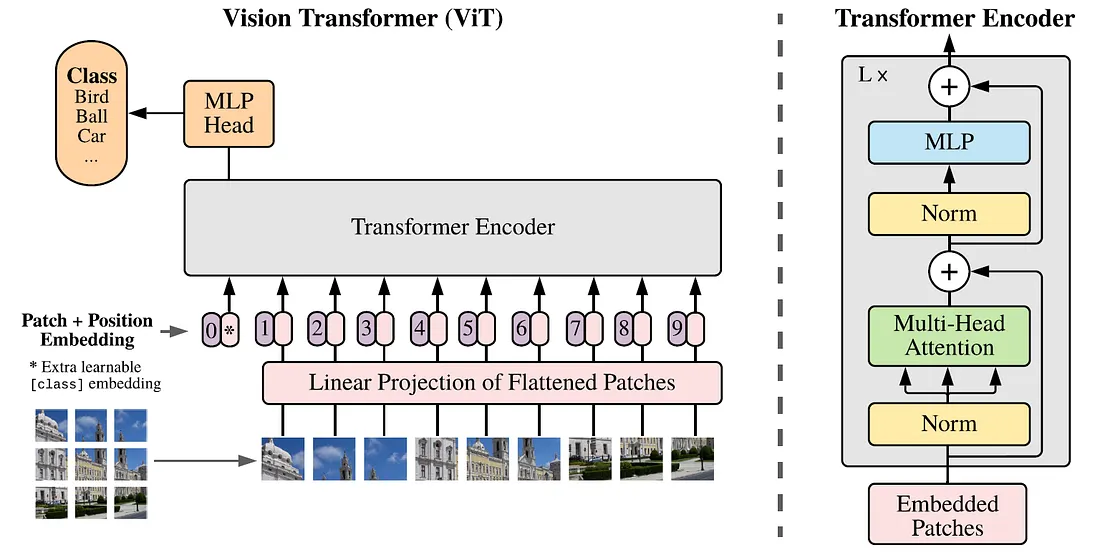

In [7]:
# class for PatchEmbedding - Part 1 of the ViT architecture

class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()     #it will inherit properties from previous 
        self.patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size= patch_size, stride = patch_size)  # it help to conv. original format into some differnt format


    def forward (self,x):
        x = self.patch_embed(x)
        x = x.flatten(2)
        x = x.transpose(1,2)
        return x
        #return self.patch_embed(x).flatten(2).transpose(1,2)  # we can use it insted of all above in 1 

In [8]:
# class for Transformer Encoder - Part 2 of the ViT architecture
# Layer Normalization
# Multi Head Attentions
# Layer Noarmalization
# residuals
#MLP - Activation Function

class TransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.multi_head_attention = nn.MultiheadAttention(embed_dim, attention_head, batch_first = True) #embeded_dim = 20 and head =4 , so every head will work on 5 dimentions 
        self.layer_norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
        nn.Linear(embed_dim, mlp_nodes),
        nn.GELU(),
        nn.Linear(mlp_nodes,embed_dim),
        #nn.GELU(),
        #nn.Linear(embed_dim),
        )

    def forward(self, x):
        residual1 = x
        attention_output = self.self_attention(self.layer_norm_1(x),self.layer_norm_1(x),self.layer_norm_1(x))[0]
        x = self.layer_norm1(x)
        x = self.multi_head_attention(x, x, x)[0] + residual1
        # we have to calculate K,Q,V key , query, Value , but it will take input as original Input
        # By writing [0], you are telling Python: "Give me the actual output data and ignore the attention 
        #weights map." If you didn't include [0], your code would crash because you'd be trying to add a 
        #tuple to a tensor (residual1). 

        
        residual2 = x
        x = self.layer_norm2(x)
        x = self.mlp(x)  + residual2
        # we adding residuals as mentioned in architecture which taken at before layer norm and added after multi head attention and MLp layer
        return x
        

In [9]:
# Class for MLP head for classification - Part 3 of the ViT Architecture 


class MLP_Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.mlphead = nn.Sequential(
            #nn.Linear(embed_dim),  # cause we alredy getting in embed_dim format
            nn.Linear(embed_dim,num_classes)
        )

    def forward(self, x):
        #x = x[:,0]   # Token at position 0
        x = self.layer_norm1(x)
        x = self.mlphead(x)
        return x

In [18]:
class VisionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embedding =  PatchEmbedding()
        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim)) # cls token should be 1, with  1 vector and dimention is embed_dim
        self.position_embedding = nn.Parameter(torch.randn(1, patch_num+1, embed_dim))  # we had added CLS token so patch_num + 1
        self.transformer_block = nn.Sequential(*[TransformerEncoder() for _ in range (transformer_unit)])   # we have to run Transformer block repeatedly
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 10))

    def forward(self,x):
        x = self.patch_embedding(x)
        B = x.shape[0]
        cls_tokens = self.cls_token.expand(B,-1,-1)
        x = torch.cat((cls_tokens, x),1)
        x = x  + self.position_embedding
        x = self.transformer_block(x)
        x = x[:,0]                    # Token at position 0
        x = self.mlp_head(x)
        return x

In [19]:
# device
#optimizer
# crossentropy

device = torch.device("cuda" if torch.cuda.is_available() else"cpu")
print(device)
model = VisionTransformer().to(device)

optimizer = torch.optim.Adam(VisionTransformer().parameters(),lr = learning_rate)
criterion =  nn.CrossEntropyLoss()

cuda


In [20]:
for epoch in range(5):
    model.train()
    total_loss = 0
    correct_epoch = 0
    total_epoch = 0
    print(f"\nEpoch {epoch+1}")

    for batch_idx, (images, labels) in enumerate(train_data):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()
        preds = outputs.argmax(dim=1)

        correct = (preds == labels).sum().item()
        accuracy = 100.0 * correct / labels.size(0)

        correct_epoch += correct
        total_epoch += labels.size(0)

        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx+1:3d}: Loss = {loss.item():.4f}, Accuracy = {accuracy:.2f}%")

    epoch_acc = 100.0 * correct_epoch / total_epoch
    print(f"==> Epoch {epoch+1} Summary: Total Loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}%")


Epoch 1
  Batch   1: Loss = 2.4787, Accuracy = 7.81%
  Batch 101: Loss = 2.4492, Accuracy = 12.50%
  Batch 201: Loss = 2.4243, Accuracy = 10.94%
  Batch 301: Loss = 2.4866, Accuracy = 12.50%
  Batch 401: Loss = 2.3543, Accuracy = 15.62%
  Batch 501: Loss = 2.5088, Accuracy = 9.38%
  Batch 601: Loss = 2.3698, Accuracy = 10.94%
  Batch 701: Loss = 2.3878, Accuracy = 12.50%
  Batch 801: Loss = 2.5027, Accuracy = 4.69%
  Batch 901: Loss = 2.3356, Accuracy = 12.50%
==> Epoch 1 Summary: Total Loss = 2292.3113, Accuracy = 9.93%

Epoch 2
  Batch   1: Loss = 2.4805, Accuracy = 10.94%
  Batch 101: Loss = 2.5980, Accuracy = 4.69%
  Batch 201: Loss = 2.5217, Accuracy = 9.38%
  Batch 301: Loss = 2.4588, Accuracy = 9.38%
  Batch 401: Loss = 2.3764, Accuracy = 12.50%
  Batch 501: Loss = 2.4484, Accuracy = 10.94%
  Batch 601: Loss = 2.3155, Accuracy = 9.38%
  Batch 701: Loss = 2.4802, Accuracy = 6.25%
  Batch 801: Loss = 2.3948, Accuracy = 7.81%
  Batch 901: Loss = 2.4329, Accuracy = 14.06%
==> Epoch

In [13]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_data:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100.0 * correct / total
print(f"\n==> Val Accuracy: {test_acc:.2f}%")



==> Val Accuracy: 10.10%


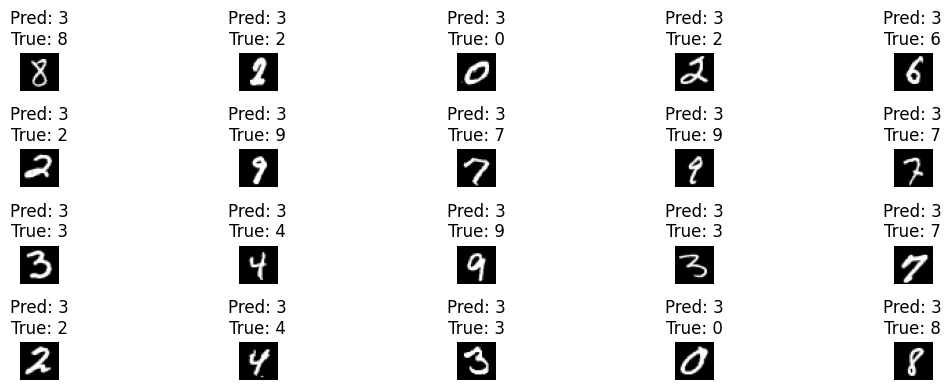

In [14]:
model.eval()
images, labels = next(iter(val_data))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

# Plot 10 test images with predictions
plt.figure(figsize=(12, 4))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')
    plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [15]:
# Get one batch from the validation data
images, labels = next(iter(val_data))

# Print the shape of the images tensor
print("Shape of images in a batch:", images.shape)
patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
embedded_data = patch_embed(images)
embedded_data = embedded_data.flatten(2)
embedded_data = embedded_data.transpose(1,2)
print("Shape of embedded data:", embedded_data.shape)
print(torch.randn(1,1,embed_dim).shape)

# You can also print the shape of the labels tensor if you'd like
# print("Shape of labels in a batch:", labels.shape)

Shape of images in a batch: torch.Size([64, 1, 28, 28])
Shape of embedded data: torch.Size([64, 16, 20])
torch.Size([1, 1, 20])


In [16]:
# To print/ check Dimensions 

images, labels = next(iter(train_data))
patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size= patch_size, stride = patch_size)  
embedded_image = patch_embed(images)


print("This is the Shape of Input image Tensor",images.shape)
print("This is the Shape of Input image Tensor after Conv2d",patch_embed(images).shape)
print(embedded_image.flatten(2).shape) # here we want embeding for 3 dimentions, now 4,4 flatten into single dimension 16

# we want embed_dim at last position so we have to transpose
print(embedded_image.flatten(2).transpose(1,2).shape)

This is the Shape of Input image Tensor torch.Size([64, 1, 28, 28])
This is the Shape of Input image Tensor after Conv2d torch.Size([64, 20, 4, 4])
torch.Size([64, 20, 16])
torch.Size([64, 16, 20])
